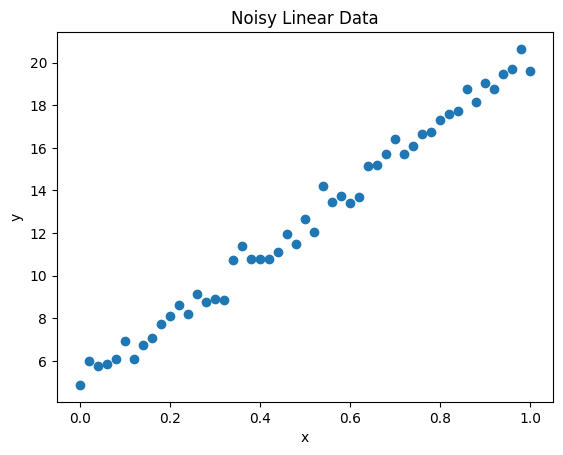

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

alp = 0.1
ep = 1e-6

m = 51
x = np.linspace(0, 1, m)

# y = 15*x + 5 + Gaussian noise (mean=0, std=0.4)
y = 15 * x + 5 + np.random.normal(0, 0.4, size=x.shape)

plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noisy Linear Data')
plt.show()


Estimated parameters:
Bias (theta0): 5.3647
Slope (theta1): 14.3698


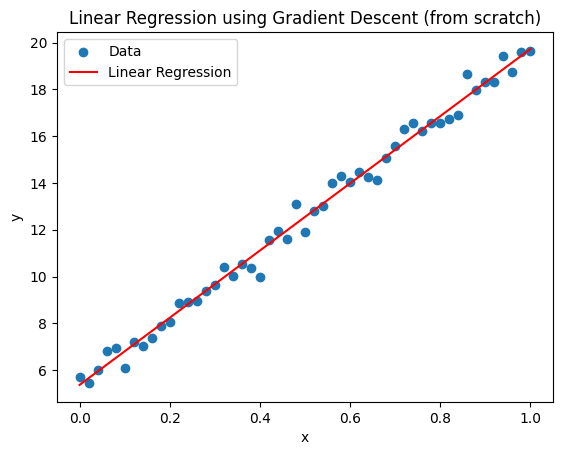

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1. Generate data
# -----------------------
np.random.seed(0)

m = 51
x = np.linspace(0, 1, m)
y = 15 * x + 5 + np.random.normal(0, 0.4, size=m)

# Add bias term (x0 = 1)
X = np.c_[np.ones(m), x]   # shape (m, 2)

# -----------------------
# 2. Initialize parameters
# -----------------------
alpha = 0.1       # learning rate
eps = 1e-6        # stopping tolerance
theta = np.zeros(2)  # [bias, slope]

# -----------------------
# 3. Cost function (MSE)
# -----------------------
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    errors = predictions - y
    return (1 / (2 * m)) * np.sum(errors ** 2)

# -----------------------
# 4. Gradient Descent
# -----------------------
def gradient_descent(X, y, theta, alpha, eps):
    m = len(y)
    cost_prev = compute_cost(X, y, theta)

    while True:
        predictions = X @ theta
        errors = predictions - y

        # Gradient
        gradients = (1 / m) * (X.T @ errors)

        # Update
        theta = theta - alpha * gradients

        cost = compute_cost(X, y, theta)

        # Convergence check
        if abs(cost_prev - cost) < eps:
            break

        cost_prev = cost

    return theta

# Run gradient descent
theta_final = gradient_descent(X, y, theta, alpha, eps)

print(f"Estimated parameters:")
print(f"Bias (theta0): {theta_final[0]:.4f}")
print(f"Slope (theta1): {theta_final[1]:.4f}")

# -----------------------
# 5. Plot results
# -----------------------
plt.scatter(x, y, label='Data')
plt.plot(x, X @ theta_final, color='red', label='Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Linear Regression using Gradient Descent (from scratch)')
plt.show()


Trained parameters:
Bias  (θ0): 5.3448
Slope (θ1): 14.4396
Test Mean Squared Error: 0.1865


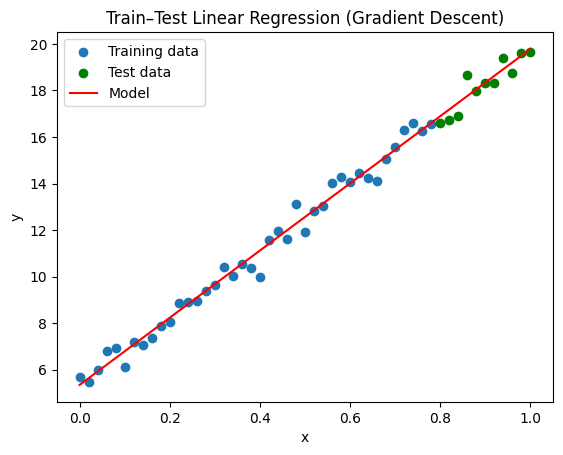

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# 1. Generate data
# -----------------------
np.random.seed(0)

m = 51
x = np.linspace(0, 1, m)
y = 15 * x + 5 + np.random.normal(0, 0.4, size=m)

# -----------------------
# 2. Train–Test Split (80–20)
# -----------------------
split_ratio = 0.8
split_index = int(m * split_ratio)

x_train = x[:split_index]
y_train = y[:split_index]

x_test = x[split_index:]
y_test = y[split_index:]

# Add bias term
X_train = np.c_[np.ones(len(x_train)), x_train]
X_test = np.c_[np.ones(len(x_test)), x_test]

# -----------------------
# 3. Cost function
# -----------------------
def compute_cost(X, y, theta):
    m = len(y)
    return (1 / (2 * m)) * np.sum((X @ theta - y) ** 2)

# -----------------------
# 4. Gradient Descent
# -----------------------
def gradient_descent(X, y, alpha=0.1, eps=1e-6):
    m, n = X.shape
    theta = np.zeros(n)
    prev_cost = compute_cost(X, y, theta)

    while True:
        gradients = (1 / m) * (X.T @ (X @ theta - y))
        theta -= alpha * gradients

        cost = compute_cost(X, y, theta)
        if abs(prev_cost - cost) < eps:
            break
        prev_cost = cost

    return theta

# -----------------------
# 5. Train model
# -----------------------
theta = gradient_descent(X_train, y_train)

print("Trained parameters:")
print(f"Bias  (θ0): {theta[0]:.4f}")
print(f"Slope (θ1): {theta[1]:.4f}")

# -----------------------
# 6. Test model
# -----------------------
y_pred_test = X_test @ theta
test_mse = (1 / len(y_test)) * np.sum((y_pred_test - y_test) ** 2)

print(f"Test Mean Squared Error: {test_mse:.4f}")

# -----------------------
# 7. Visualization
# -----------------------
plt.scatter(x_train, y_train, label="Training data")
plt.scatter(x_test, y_test, label="Test data", color='green')

x_line = np.linspace(0, 1, 100)
X_line = np.c_[np.ones(len(x_line)), x_line]
plt.plot(x_line, X_line @ theta, color='red', label="Model")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Train–Test Linear Regression (Gradient Descent)")
plt.show()
